In [1]:
import os
import subprocess
try:
    _printenv = subprocess.run(
        ['bash', '-c', 'source ~/.bashrc 2>/dev/null && printenv'],
        text=True, capture_output=True, timeout=10,
    ).stdout
    for _line in _printenv.splitlines():
        if '=' in _line:
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k, _v)
except Exception:
    pass
if 'PDK_ROOT' in os.environ and 'PDK' in os.environ:
    os.environ.setdefault('PDKPATH', os.path.join(os.environ['PDK_ROOT'], os.environ['PDK']))

import gdstk
import svgutils.transform as sg
import IPython.display
from IPython.display import clear_output
import ipywidgets as widgets

# Redirect all outputs here
hide = widgets.Output()

def display_gds(gds_file,path,scale = 3):
  
  # Generate an SVG image
  top_level_cell = gdstk.read_gds(gds_file).top_level()[0]
  top_level_cell.write_svg(os.path.join(path,'out.svg'))
    
  # Scale the image for displaying
  fig = sg.fromfile(os.path.join(path,'out.svg'))
  fig.set_size((str(float(fig.width) * scale), str(float(fig.height) * scale)))
  fig.save(os.path.join(path,'out.svg'))

  # Display the image
  IPython.display.display(IPython.display.SVG(os.path.join(path,'out.svg')))
  os.remove(os.path.join(path,'out.gds'))

def display_component(component,path,scale = 3):
  # Save to a GDS file
  with hide:
    component.write_gds(os.path.join(path,'out.gds'))
  display_gds(os.path.join(path,'out.gds'),path,scale)


# %%
import os
import gdsfactory as gf
from gdsfactory import Component
from glayout import MappedPDK, gf180
from glayout import nmos, pmos
from glayout import via_stack
from glayout import rename_ports_by_orientation
from glayout import tapring
from glayout.primitives.mimcap import mimcap_array
from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route
from glayout.util.comp_utils import evaluate_bbox, prec_center, prec_ref_center, align_comp_to_port
from glayout.util.port_utils import add_ports_perimeter,print_ports
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.spice.netlist import Netlist


# Base parameters for PMOS and NMOS
stdp_config = {
    "pdk": gf180,
    "layout_rules": {
        "spacing": gf180.util_max_metal_seperation()+1,
        "routing_metal": "met2",
        "dummy_devices": False,
        "tie_layers": ("met2", "met1"),
        "sd_rmult": 1,
    },
}

nmos_kwargs = {
    "with_tie": True,
    "with_dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": False,
    "with_substrate_tap":False
}

pmos_kwargs = {
    "with_tie": True,
    "dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": False,
    "with_substrate_tap":False
}



In [2]:
pdk = gf180
current_mirror = Component(name="current_mirror")
current_mirror.name = "current_mirror"
rules = stdp_config["layout_rules"]
spacing = rules["spacing"]
tie_layers = rules["tie_layers"]
sd_rmult = rules["sd_rmult"]


#Placement
m1 = nmos(pdk, width=4, length=0.28, with_dummy=(False, False),  tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
m2 = nmos(pdk, width=4, length=4, with_dummy=(False, False),  tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
m3 = pmos(pdk, width=8, length=0.5, with_dummy=(False, False),  tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
m4 = pmos(pdk, width=1.6, length=0.5, with_dummy=(False, False), tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)

m1.name = "m1" 
m2.name = "m2" 
m3.name = "m3" 
m4.name = "m4" 

m1_ref = current_mirror << m1
m2_ref = current_mirror << m2
m3_ref = current_mirror << m3
m4_ref = current_mirror << m4


bottom_row_y = evaluate_bbox(m1)[1]/2 + 4
top_row_y = bottom_row_y + evaluate_bbox(m3)[1]

m1_ref.move((evaluate_bbox(m1)[0]/2,bottom_row_y))
m2_ref.move((m1_ref.xmax + evaluate_bbox(m2_ref)[0]/2 + spacing , bottom_row_y))


m4_ref.move((evaluate_bbox(m1)[0]/2 ,top_row_y ))
m3_ref.move((m4_ref.xmax + evaluate_bbox(m3)[0]/2 + spacing,top_row_y))



2026-08-18 01:58:21.748 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


ComponentReference (parent Component "m3", ports ['multiplier_0_gate_W', 'gate_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_layer_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_via_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_met_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_top_met_W', 'multiplier_0_leftsd_array_row0_col0_bottom_layer_W', 'multiplier_0_leftsd_array_row0_col0_bottom_via_W', 'multiplier_0_leftsd_array_row0_col0_bottom_met_W', 'multiplier_0_leftsd_array_row0_col0_top_met_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_bottom_layer_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_bottom_via_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_bottom_met_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_top_met_W', 'multiplier_0_leftsd_array_row1_col0_bottom_layer_W', 'multiplier_0_leftsd_array_row1_col0_bottom_via_W', 'multiplier_0_leftsd_array_row1_col0_bottom_met_W', 'multiplier_0_leftsd_array_row1_col0_top_met_W', '

In [3]:
help(nmos)

Help on function nmos in module glayout.primitives.fet:

nmos(pdk, width: float = 3, fingers: Optional[int] = 1, multipliers: Optional[int] = 1, with_tie: bool = True, with_dummy: Union[bool, tuple[bool, bool]] = True, with_dnwell: bool = True, with_substrate_tap: bool = True, length: Optional[float] = None, sd_route_topmet: str = 'met2', gate_route_topmet: str = 'met2', sd_route_left: bool = True, rmult: Optional[int] = None, sd_rmult: int = 1, gate_rmult: int = 1, interfinger_rmult: int = 1, tie_layers: tuple[str, str] = ('met2', 'met1'), substrate_tap_layers: tuple[str, str] = ('met2', 'met1'), dummy_routes: bool = True) -> gdsfactory.component.Component
    Generic NMOS generator
    pdk: mapped pdk to use
    width: expands the NMOS in the y direction
    fingers: introduces additional fingers (sharing source/drain) of width=width
    multipliers: number of multipliers (a multiplier is a row of fingers)
    with_tie: true or false, specfies if a bulk tie is required
    with_dummy

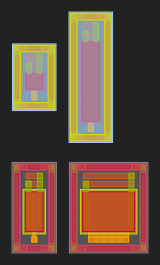

In [4]:
# stdp_comp.show()
display_component(current_mirror, scale = 1,path=".")

In [5]:
# =========================================================================
# 4. ADD AVDD & AVSS POWER RAILS AND CONNECT SUPPLY NODES
# =========================================================================

# https://gemini.google.com/app/131a537106def8cd
# Calculate full horizontal span of the cell to draw supply rails
bbox = evaluate_bbox(current_mirror)
top_y = current_mirror.ymax + 2.0
bottom_y = current_mirror.ymin - 2.0

# Draw horizontal metal2 power rails
avdd_rail = current_mirror << gf.components.rectangle(
    size=(bbox[0]+4, 1.0), 
    layer=pdk.get_layer("metal2")
)
avdd_rail.move((-2, top_y))

avss_rail = current_mirror << gf.components.rectangle(
    size=(bbox[0]+4, 1.0), 
    layer=pdk.get_layer("metal2")
)
avss_rail.move((-2, bottom_y))

# Add global ports for the supply rails
current_mirror.add_port("avdd", center=(bbox[0]/2, top_y + 0.5), width=1.0, orientation=180, layer=pdk.get_layer("metal2"), port_type="electrical")
current_mirror.add_port("avss", center=(bbox[0]/2, bottom_y + 0.5), width=1.0, orientation=180, layer=pdk.get_layer("metal2"), port_type="electrical")
# add label to those global ports 
current_mirror.add_label(text="avdd", position=(bbox[0]/2, top_y + 0.5), layer=pdk.get_glayer("met2_label") , magnification=1.5)
current_mirror.add_label(text="avss", position=(bbox[0]/2, bottom_y + 0.5), layer=pdk.get_glayer("met2_label") , magnification=1.5)


Label(text='avss', origin=(6.8, 2.5), layer=(36, 10))

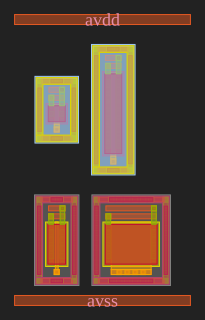

In [6]:
# stdp_comp.show()
display_component(current_mirror, scale = 1,path=".")

In [7]:
# Connect PMOS bulks to avdd rail
current_mirror << L_route(pdk, m4_ref.ports["tie_W_top_met_N"], current_mirror.ports["avdd"])
current_mirror << L_route(pdk, m3_ref.ports["tie_W_top_met_N"], current_mirror.ports["avdd"])

# Connect NMOS BULKS TO AVSS
current_mirror << L_route(pdk, m1_ref.ports["tie_W_top_met_S"], current_mirror.ports["avss"])
current_mirror << L_route(pdk, m2_ref.ports["tie_W_top_met_S"], current_mirror.ports["avss"])

#connecting PMOS SOURCES TO AVDD
current_mirror << L_route(pdk,  m4_ref.ports["multiplier_0_source_E"], m4_ref.ports["tie_E_top_met_N"])  # SOURCE m4
current_mirror << L_route(pdk,  m3_ref.ports["multiplier_0_source_E"], m3_ref.ports["tie_E_top_met_N"])  # SOURCE M3

#CONNECTING NMOS SOURCE TO AVSS
current_mirror << L_route(pdk,  m1_ref.ports["multiplier_0_source_E"], m1_ref.ports["tie_E_top_met_N"]) #m1
current_mirror << L_route(pdk,  m2_ref.ports["multiplier_0_source_E"], m2_ref.ports["tie_E_top_met_N"]) #m2

ComponentReference (parent Component "L_route_1576841e", ports ['bottom_layer_W', 'bottom_via_W', 'bottom_met_W', 'top_met_W', 'bottom_layer_N', 'bottom_via_N', 'bottom_met_N', 'top_met_N', 'bottom_layer_E', 'bottom_via_E', 'bottom_met_E', 'top_met_E', 'bottom_layer_S', 'bottom_via_S', 'bottom_met_S', 'top_met_S'], origin (0.0, 0.0), rotation 0.0, x_reflection False)

In [8]:
#NODE A
viam2m3 = via_stack(pdk, "met2", "met3", centered=True) #met2 is the bottom layer. met3 is the top layer.
node_A_via = current_mirror << viam2m3
node_A_via_2 = current_mirror << viam2m3
node_A_via.move(m4_ref.ports["gate_S"].center).movex(2.8).movey(-5)
node_A_via_2.move(m4_ref.ports["gate_S"].center).movex(-2.5).movey(-5)
current_mirror << L_route(pdk, m4_ref.ports["drain_W"], node_A_via_2.ports["top_met_N"])
current_mirror << L_route(pdk, m1_ref.ports["drain_W"], node_A_via_2.ports["top_met_S"])
current_mirror << L_route(pdk, m4_ref.ports["gate_W"], node_A_via_2.ports["top_met_N"])
current_mirror << L_route(pdk, m1_ref.ports["gate_W"], node_A_via_2.ports["top_met_S"])
current_mirror << straight_route(pdk, node_A_via_2.ports["bottom_met_W"], node_A_via.ports["bottom_met_E"])
current_mirror << L_route(pdk, m2_ref.ports["gate_W"], node_A_via.ports["top_met_S"])

ComponentReference (parent Component "L_route_89f52689", ports ['array_row0_col0_bottom_layer_W', 'array_row0_col0_bottom_via_W', 'array_row0_col0_bottom_met_W', 'array_row0_col0_top_met_W', 'bottom_lay_W', 'top_met_W', 'array_row0_col0_bottom_layer_N', 'array_row0_col0_bottom_via_N', 'array_row0_col0_bottom_met_N', 'array_row0_col0_top_met_N', 'bottom_lay_N', 'top_met_N', 'array_row0_col0_bottom_layer_E', 'array_row0_col0_bottom_via_E', 'array_row0_col0_bottom_met_E', 'array_row0_col0_top_met_E', 'bottom_lay_E', 'top_met_E', 'array_row0_col0_bottom_layer_S', 'array_row0_col0_bottom_via_S', 'array_row0_col0_bottom_met_S', 'array_row0_col0_top_met_S', 'bottom_lay_S', 'top_met_S'], origin (0.0, 0.0), rotation 0.0, x_reflection False)

In [9]:
#NODE B
node_B_via = current_mirror << viam2m3
node_B_via.move(m3_ref.ports["gate_S"].center).movex(2.8).movey(-2)
current_mirror << c_route(pdk, m3_ref.ports["drain_E"], node_B_via.ports["bottom_met_E"])
current_mirror << c_route(pdk, m3_ref.ports["gate_E"], node_B_via.ports["bottom_met_E"])
current_mirror << c_route(pdk, m2_ref.ports["drain_W"], node_B_via.ports["bottom_met_W"])


ComponentReference (parent Component "c_route_52019428", ports ['con_N', 'con_S'], origin (0.0, 0.0), rotation 0.0, x_reflection False)

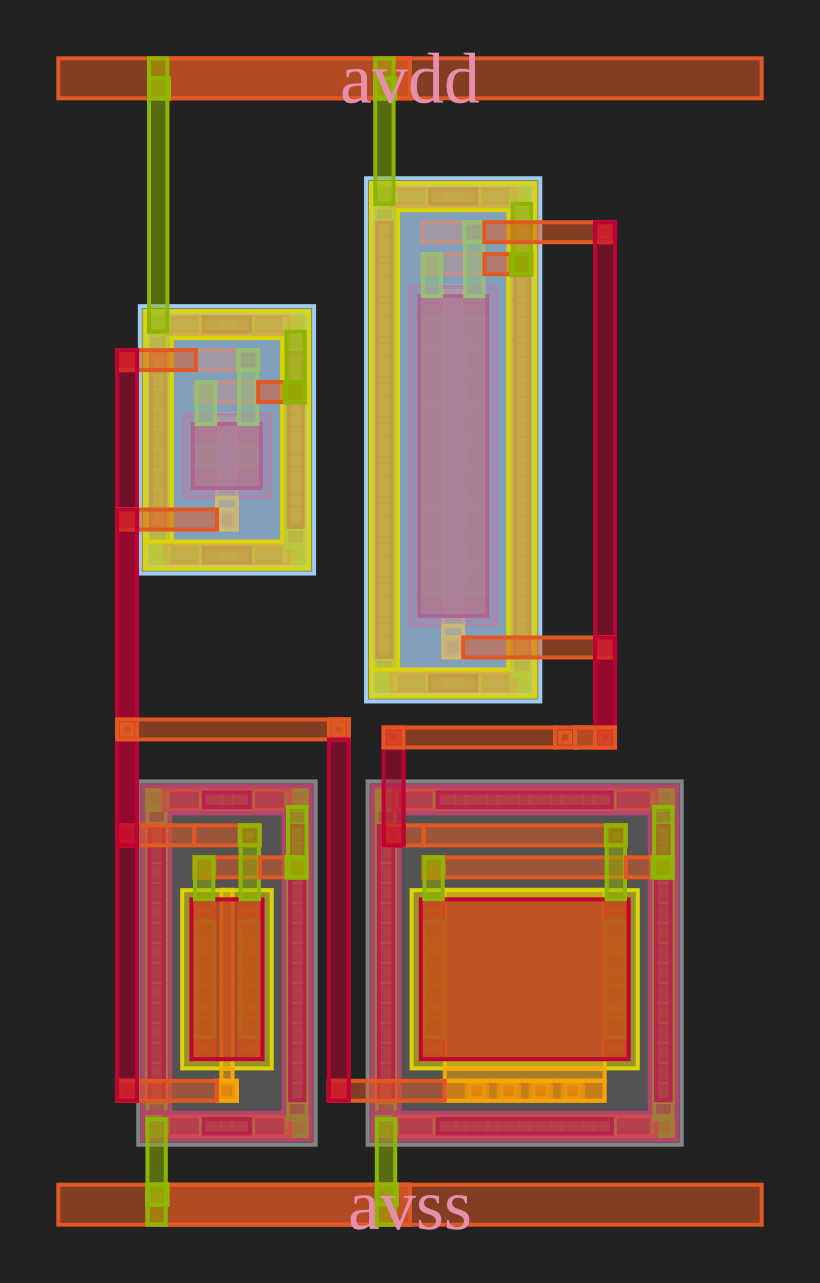

In [10]:
# stdp_comp.show()
display_component(current_mirror, scale = 4,path=".")

In [11]:
# =========================================================================
# 5. ADD MET2 PHYSICAL PINS AND LABELS FOR LVS
# =========================================================================

# Map port names to their source port objects
pins_to_create = {
    "A": node_A_via.ports["top_met_N"],
    "B": node_B_via.ports["top_met_N"]
}

for pin_name, port in pins_to_create.items():
    # Extract center position, size, and orientation from port object
    center = port.center
    width = port.width
    height = port.width  # Standard square pin area around the port center

    # 1. Add pin rectangle shape on met2_pin
    current_mirror.add_polygon(
        [
            (center[0] - width / 2, center[1] - height / 2),
            (center[0] + width / 2, center[1] - height / 2),
            (center[0] + width / 2, center[1] + height / 2),
            (center[0] - width / 2, center[1] + height / 2),
        ],
        layer=pdk.get_glayer("met2_label") ,
    )
   
    current_mirror.add_port(pin_name, center=center, width=1.0, orientation=180, layer=pdk.get_glayer("met2"),  port_type="electrical") 

    # 2. Add text label on met2_pin layer for net identity
    current_mirror.add_label(
        text=pin_name, position=center, layer=pdk.get_glayer("met2_label"), magnification=1.2
    )
    


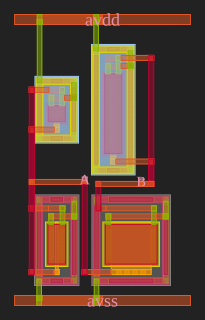

In [12]:

display_component(current_mirror, scale = 1,path=".")

In [13]:
current_mirror.pprint_ports()

┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┓
┃ name ┃ width ┃ center         ┃ orientation ┃ layer   ┃ port_type  ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━┩
│ avdd │ 1.0   │ [6.8, 30.68]   │ 180         │ [36, 0] │ electrical │
│ avss │ 1.0   │ [6.8, 2.5]     │ 180         │ [36, 0] │ electrical │
│ A    │ 1.0   │ [5.02, 14.64]  │ 180         │ [36, 0] │ electrical │
│ B    │ 1.0   │ [10.68, 14.44] │ 180         │ [36, 0] │ electrical │
└──────┴───────┴────────────────┴─────────────┴─────────┴────────────┘

In [14]:
evaluate_bbox(current_mirror)

(17.6, 29.18)

In [15]:
current_mirror_est_area = evaluate_bbox(current_mirror)[0] * evaluate_bbox(current_mirror)[1]
current_mirror_est_area

513.568

In [16]:
netlist = Netlist(circuit_name="current_mirror", nodes=['avss', 'avdd', 'B', 'A'])
netlist.connect_netlist(m1_ref.info['netlist'], [('D', 'A'),   ('G', 'A'),   ('S', 'avss'), ('B', 'avss')])
netlist.connect_netlist(m2_ref.info['netlist'], [('D', 'B'),   ('G', 'A'),   ('S', 'avss'), ('B', 'avss')])
netlist.connect_netlist(m3_ref.info['netlist'], [('D', 'B'),   ('G', 'B'),   ('S', 'avdd'), ('B', 'avdd')])
netlist.connect_netlist(m4_ref.info['netlist'], [('D', 'A'),   ('G', 'A'),   ('S', 'avdd'), ('B', 'avdd')])

current_mirror.info["netlist"] = netlist
print(current_mirror.info['netlist'].generate_netlist())

.subckt NMOS D G S B DUM l=0.28 w=4
XMAIN1 D G S B nfet_03v3 l=0.28 w=4
.ends NMOS

.subckt NMOS_1 D G S B DUM l=4 w=4
XMAIN1 D G S B nfet_03v3 l=4 w=4
.ends NMOS_1

.subckt PMOS D G S B DUM l=0.5 w=8
XMAIN1 D G S B pfet_03v3 l=0.5 w=8
.ends PMOS

.subckt PMOS_1 D G S B DUM l=0.5 w=1.6
XMAIN1 D G S B pfet_03v3 l=0.5 w=1.6
.ends PMOS_1

.subckt current_mirror avss avdd B A
X0 A A avss avss DUM NMOS l=0.28 w=4
X1 B A avss avss DUM NMOS_1 l=4 w=4
X2 B B avdd avdd DUM PMOS l=0.5 w=8
X3 A A avdd avdd DUM PMOS_1 l=0.5 w=1.6
.ends current_mirror


In [17]:
import os
from pathlib import Path
path_to_dir = "/foss/designs/libs/snn_analog/current_mirror/"

pex_path = path_to_dir + f"{current_mirror.name}.spice"
gds_path = path_to_dir + f"{current_mirror.name}.gds"
current_mirror.write_gds(str(gds_path))

2026-08-18 01:58:27.497 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/foss/designs/libs/snn_analog/current_mirror/current_mirror.gds'


PosixPath('/foss/designs/libs/snn_analog/current_mirror/current_mirror.gds')

In [18]:
drc_result = gf180.drc_magic(current_mirror, current_mirror.name)

2026-08-18 01:58:27.531 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpl8epvmu4/current_mirror.gds'


using default pdk_root
Defaulting to stale magic_commands.tcl

Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:17:18 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpl8epvmu4/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0

In [19]:
import os
from pathlib import Path
path_to_dir = "/foss/designs/libs/snn_analog/current_mirror/"

gf180.lvs_netgen(
    layout=current_mirror,
    design_name = current_mirror.name,
    pdk_root = Path(os.environ['PDKPATH']),
    lvs_setup_tcl_file = Path(os.environ['PDKPATH']) / "libs.tech" / "netgen" / f"{os.environ['PDK']}_setup.tcl",
    netlist = Path(str(path_to_dir + "current_mirror_sch.spice")),
    output_file_path =  Path(str(path_to_dir))
)



2026-08-18 01:58:27.900 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpcyco30s0/current_mirror.gds'


using user specified pdk_root, will search for required files in the specified directory

Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:17:18 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.575-2-g7b70722
Library written using

{'magic_subproc_code': 0,
 'netgen_subproc_code': 0,
 'result_str': 'LVS run succeeded\nErrors found in LVS report: /tmp/tmpcyco30s0/current_mirror_lvs.rpt'}